## 5. Modelado y evaluación

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from tensorflow.keras import layers, Model
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

import optuna


# Paths
X_train_in = Path("../data/modeling/supervised/X_train.parquet")
X_test_in = Path("../data/modeling/supervised/X_test.parquet")
y_train_in = Path("../data/modeling/supervised/y_train.parquet")
y_test_in = Path("../data/modeling/supervised/y_test.parquet")

X_train_N_in = Path("../data/modeling/unsupervised/X_train_N.parquet")
X_test_N_in = Path("../data/modeling/unsupervised/X_test_N.parquet")
y_test_N_in = Path("../data/modeling/unsupervised/y_test_N.parquet")

I0000 00:00:1780010126.148737   13320 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### 1) Revisión general

Cargo los diferentes conjuntos preparados para usar en los diferentes modelos.

In [2]:
X_train = pd.read_parquet(X_train_in)
X_test = pd.read_parquet(X_test_in)
y_train = pd.read_parquet(y_train_in)
y_test = pd.read_parquet(y_test_in)

X_train_N = pd.read_parquet(X_train_N_in)
X_test_N = pd.read_parquet(X_test_N_in)
y_test_N = pd.read_parquet(y_test_N_in)

Soluciono un par de errores de tipo pd a np: 

In [3]:
y_train = y_train.squeeze().to_numpy()
y_test = y_test.squeeze().to_numpy()
X_train = X_train.squeeze().to_numpy()
X_test = X_test.squeeze().to_numpy()

#### 2) Modelos Supervisados

Dada la separación hecha en el notebook 4 más la codificación de la variable respuesta en este caso '0' representa Ataque y '1' Benigno.

**XGBoost**

In [4]:
# Weights adjustment
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 0.23954031489854005


In [7]:
def objective(trial):

    model = XGBClassifier(

        n_estimators=trial.suggest_int("n_estimators", 300, 1000),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1),

        max_depth=trial.suggest_int("max_depth", 4, 10),

        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),

        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),

        gamma=trial.suggest_float("gamma", 0.0, 1.0),

        reg_alpha=trial.suggest_float("reg_alpha", 0.0, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 3.0),

        scale_pos_weight=scale_pos_weight,

        tree_method="hist",
        device="cuda",

        eval_metric="logloss",

        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="average_precision"
    ).mean()

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(study.best_params)

[I 2026-05-27 20:49:35,343] A new study created in memory with name: no-name-f9bbf6a7-ad81-4f7b-bf1e-58c4bcba5085
/home/adrian/Documentos/TFG/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:49:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7f4dbd6e5700>>
Traceback (most recent call last):
  File "/home/adrian/Documentos/TFG/venv/lib/python3.12/site-packages/xgboost/core.py", line 607, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 
Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x7f4dbd6e4890>>
Traceback (most recent call last):
  File "/home/adrian

In [ ]:
best_params = study.best_params

model = XGBClassifier(
    **best_params,
    tree_method="hist",
    device="cuda",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=50,
    verbose=50
)

In [5]:
# Creation Base model of XGBoost
base_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=8,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,
    gamma=0.1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    device="cuda",

    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)

# Train Base model
base_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.66958
[50]	validation_0-logloss:0.21879
[100]	validation_0-logloss:0.14169
[150]	validation_0-logloss:0.12365
[200]	validation_0-logloss:0.11836
[250]	validation_0-logloss:0.11536
[300]	validation_0-logloss:0.11319
[350]	validation_0-logloss:0.11155
[399]	validation_0-logloss:0.11034


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [6]:
# PREDICTIONS
y_pred = base_model.predict(X_test)
y_proba = base_model.predict_proba(X_test)[:, 1]

# BASE MODEL EVALUATION
print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

/home/adrian/Documentos/TFG/venv/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [01:16:59] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



=== CONFUSION MATRIX ===
[[ 75225   8010]
 [  5963 341514]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.93      0.90      0.92     83235
           1       0.98      0.98      0.98    347477

    accuracy                           0.97    430712
   macro avg       0.95      0.94      0.95    430712
weighted avg       0.97      0.97      0.97    430712

ROC-AUC: 0.9881126608011002
PR-AUC: 0.9968487842005201


In [ ]:
# FEATURE IMPORTANCE
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": base_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Features:")
print(importance.head(20))

**Random Forest**

In [7]:
# Random Forest uses class_weight instead of scale_pos_weight
rf_model = RandomForestClassifier(
    n_estimators=100,          # increase for final model (500–1000)
    max_depth=10,              # controls overfitting

    min_samples_split=10,
    min_samples_leaf=5,

    max_features="sqrt",

    class_weight="balanced",  # IMPORTANT for IDS imbalance

    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Train model
rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.1min finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [8]:
# PREDICTIONS
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

# EVALUATION
print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.0s finished



=== CONFUSION MATRIX ===
[[ 72623  10612]
 [  1157 346320]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.87      0.93     83235
           1       0.97      1.00      0.98    347477

    accuracy                           0.97    430712
   macro avg       0.98      0.93      0.95    430712
weighted avg       0.97      0.97      0.97    430712


ROC-AUC: 0.982109795794558
PR-AUC: 0.9950847758090717


In [ ]:
# FEATURE IMPORTANCE
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTOP 20 FEATURES:")
print(importances.head(20))

#### 3) Modelos No Supervisados

**Isolation Forest**

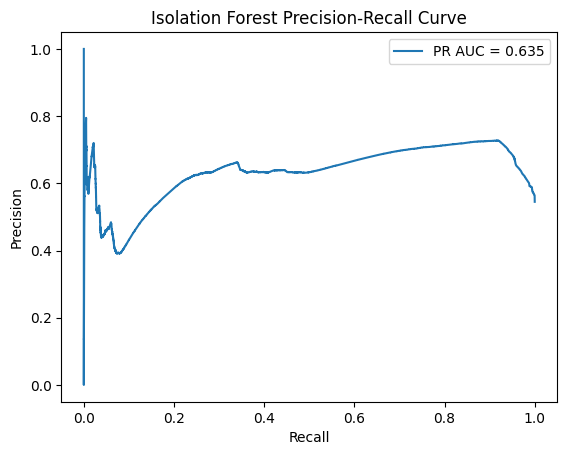


Best threshold: -0.1271845457626662

=== CONFUSION MATRIX ===
[[203194 144283]
 [ 32985 383189]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       0.86      0.58      0.70    347477
         1.0       0.73      0.92      0.81    416174

    accuracy                           0.77    763651
   macro avg       0.79      0.75      0.75    763651
weighted avg       0.79      0.77      0.76    763651


ROC-AUC: 0.6973511111462033
PR-AUC: 0.6346714883868421


In [9]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

# TRAIN
model.fit(X_train_N)

# ANOMALY SCORES
# higher = more anomalous
scores = -model.decision_function(X_test_N)

# TRUE LABELS
# 1 = attack
# 0 = benign
y_true = y_test_N

# PR CURVE
precision, recall, thresholds = precision_recall_curve(y_true, scores)

# PR-AUC
pr_auc = average_precision_score(y_true, scores)

# PLOT
plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Isolation Forest Precision-Recall Curve")
plt.legend()
plt.show()

# BEST THRESHOLD (F1)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-9
)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\nBest threshold:", best_threshold)

# PREDICTIONS
# 1 = attack
# 0 = benign
y_pred = (scores >= best_threshold).astype(int)

# EVALUATION
print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test_N, y_pred))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_N, y_pred))

print("\nROC-AUC:", roc_auc_score(y_true, scores))
print("PR-AUC:", pr_auc)

**Autoencoder**

In [10]:
# =====================================================
# LABELS (NO FLIPPING NEEDED)
# =====================================================
y_true = y_test_N  # 1 = attack, 0 = benign

# =====================================================
# MODEL (FASTER VERSION)
# =====================================================
inp = layers.Input(shape=(X_train_N.shape[1],))

x = layers.Dense(64, activation="relu")(inp)
x = layers.Dense(32, activation="relu")(x)

latent = layers.Dense(16, activation="relu")(x)

x = layers.Dense(32, activation="relu")(latent)
x = layers.Dense(64, activation="relu")(x)

out = layers.Dense(X_train_N.shape[1])(x)

autoencoder = Model(inp, out)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mae"
)

# =====================================================
# TRAIN (BENIGN ONLY) — FASTER
# =====================================================
autoencoder.fit(
    X_train_N,
    X_train_N,
    epochs=10,              # reduced from 40
    batch_size=256,         # slightly faster
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# =====================================================
# SCORES (RECONSTRUCTION ERROR)
# =====================================================
recon = autoencoder.predict(X_test_N, verbose=0)
scores = np.mean(np.abs(X_test_N - recon), axis=1)

# =====================================================
# THRESHOLD (PR OPTIMIZED)
# =====================================================
precision, recall, thresholds = precision_recall_curve(y_true, scores)
pr_auc = average_precision_score(y_true, scores)

f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
best_threshold = thresholds[np.argmax(f1)]

print("\nBest threshold:", best_threshold)

# =====================================================
# PREDICTIONS
# =====================================================
# 1 = attack, 0 = benign
y_pred = (scores >= best_threshold).astype(int)

# =====================================================
# EVALUATION
# =====================================================
print("\n=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test_N, y_pred))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test_N, y_pred))

print("\nROC-AUC:", roc_auc_score(y_true, scores))
print("PR-AUC:", pr_auc)

W0000 00:00:1780010694.167539   14121 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1780010694.449387   13320 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.7068 - val_loss: 0.1204
Epoch 2/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.9714 - val_loss: 0.1071
Epoch 3/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.8036 - val_loss: 0.3477
Epoch 4/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.8011 - val_loss: 0.0963
Epoch 5/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.6150 - val_loss: 0.0829
Epoch 6/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.7331 - val_loss: 0.0935
Epoch 7/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.5715 - val_loss: 0.0939
Epoch 8/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.6523 - val_loss: 0.0919
Epoch 9/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.5347 - val_loss: 0.0846
Epoch 10/10
4887/4887 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.6739 - val_loss: 0.0908

Best threshold: 0.1113951571486464

=== CONFUSION MATRIX ===
[[271572  75905]
 [ 43507 372667]]

=== CLASSIF